# Atividade III — Regressão Logística — Previsão de Sobrevivência no Titanic

**Aluno:** Cauê Reis

**Disciplina:** Aprendizagem de Máquina Profundo

**Professor:** Cleanderson R. Fidelis

---

## Dataset Titanic — Classificação Binária com Regressão Logística

**Objetivo:** Ajustar um modelo de **Regressão Logística** para prever a probabilidade de sobrevivência (`Survived`) dos passageiros do RMS Titanic com base em características como classe de embarque, sexo e idade. O relatório cobre as etapas de exploração de dados, pré-processamento (incluindo tratamento de valores ausentes), ajuste do modelo, avaliação com métricas de Acurácia e Curva ROC, e interpretação dos resultados.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

### 1. Carregamento dos Dados

In [3]:
df = sns.load_dataset('titanic')

df = df.rename(columns={
    'survived': 'Survived',
    'pclass':   'Pclass',
    'sex':      'Sex',
    'age':      'Age',
    'sibsp':    'SibSp',
    'parch':    'Parch',
    'fare':     'Fare',
    'embarked': 'Embarked'
})


df[['Survived','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']].head(8)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
5,0,3,male,NaN,0,0,8.4583,Q
6,0,1,male,54.0,0,0,51.8625,S
7,0,3,male,2.0,3,1,21.0750,S


### 2. Análise Exploratória dos Dados (EDA)

In [4]:
print(f'Dimensões do dataset: {df.shape[0]} linhas × {df.shape[1]} colunas\n')
print('Tipos de dados e valores ausentes:')
info = pd.DataFrame({
    'Tipo':     df.dtypes,
    'Ausentes': df.isnull().sum(),
    '% Ausentes': (df.isnull().mean() * 100).round(2)
})
print(info[['Tipo','Ausentes','% Ausentes']])

Dimensões do dataset: 891 linhas × 15 colunas

Tipos de dados e valores ausentes:
                 Tipo  Ausentes  % Ausentes
Survived        int64         0        0.00
Pclass          int64         0        0.00
Sex            object         0        0.00
Age           float64       177       19.87
SibSp           int64         0        0.00
Parch           int64         0        0.00
Fare          float64         0        0.00
Embarked       object         2        0.22
class        category         0        0.00
who            object         0        0.00
adult_male       bool         0        0.00
deck         category       688       77.22
embark_town    object         2        0.22
alive          object         0        0.00
alone            bool         0        0.00


In [7]:
df[['Age','Fare','SibSp','Parch']].describe().round(2)

,Age,Fare,SibSp,Parch
count,714.00,891.00,891.00,891.00
mean,29.70,32.20,0.52,0.38
std,14.53,49.69,1.10,0.81
min,0.42,0.00,0.00,0.00
25%,20.12,7.91,0.00,0.00
50%,28.00,14.45,0.00,0.00
75%,38.00,31.00,1.00,0.00
max,80.00,512.33,8.00,6.00


In [6]:
sobrev = df['Survived'].value_counts()
print('Distribuição de Survived:')
print(f'  Não sobreviveu (0): {sobrev[0]}  ({sobrev[0]/len(df)*100:.1f}%)')
print(f'  Sobreviveu     (1): {sobrev[1]}  ({sobrev[1]/len(df)*100:.1f}%)')

Distribuição de Survived:
  Não sobreviveu (0): 549  (61.6%)
  Sobreviveu     (1): 342  (38.4%)


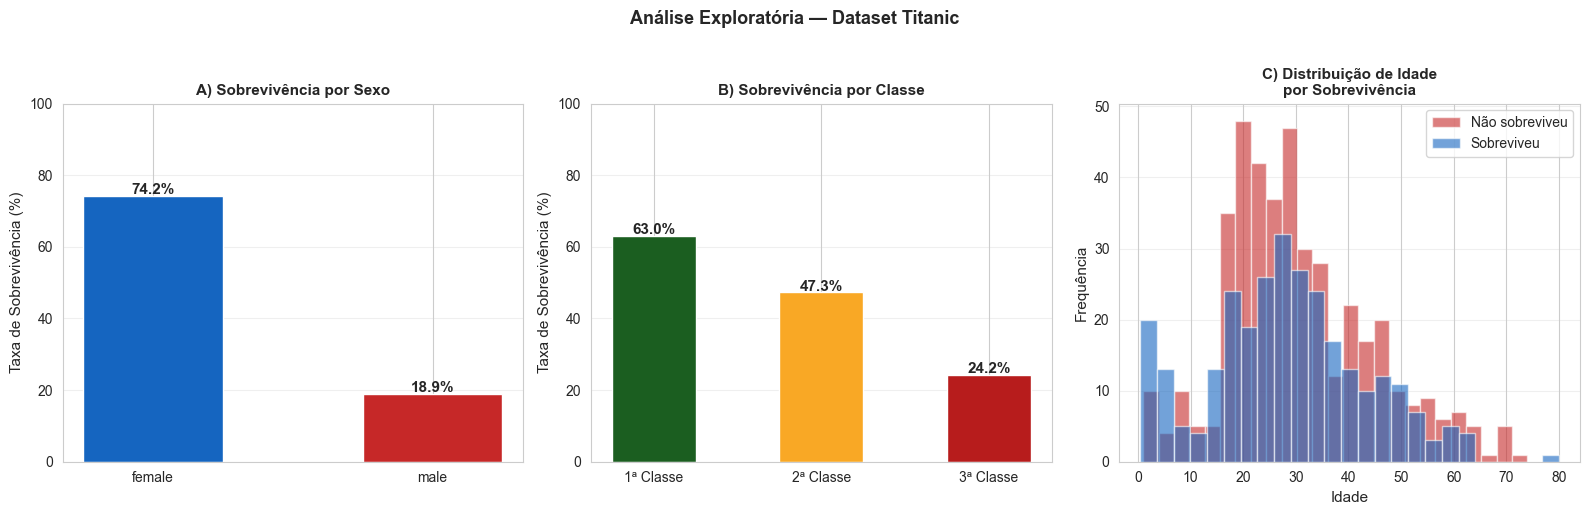

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sobrevivência por Sexo
ax = axes[0]
surv_sex = df.groupby('Sex')['Survived'].mean().reset_index()
bars = ax.bar(surv_sex['Sex'], surv_sex['Survived'] * 100,
              color=['#1565C0','#C62828'], edgecolor='white', width=0.5)
for bar, val in zip(bars, surv_sex['Survived'] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Taxa de Sobrevivência (%)', fontsize=11)
ax.set_title('A) Sobrevivência por Sexo', fontsize=11, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# Sobrevivência por Classe
ax = axes[1]
surv_class = df.groupby('Pclass')['Survived'].mean().reset_index()
cores_c = ['#1B5E20','#F9A825','#B71C1C']
bars2 = ax.bar([f'{c}ª Classe' for c in surv_class['Pclass']],
               surv_class['Survived'] * 100,
               color=cores_c, edgecolor='white', width=0.5)
for bar, val in zip(bars2, surv_class['Survived'] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Taxa de Sobrevivência (%)', fontsize=11)
ax.set_title('B) Sobrevivência por Classe', fontsize=11, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# Distribuição de Idade por Sobrevivência
ax = axes[2]
df[df['Survived'] == 0]['Age'].dropna().hist(ax=ax, bins=25, alpha=0.6,
                                             color='#C62828', label='Não sobreviveu')
df[df['Survived'] == 1]['Age'].dropna().hist(ax=ax, bins=25, alpha=0.6,
                                             color='#1565C0', label='Sobreviveu')
ax.set_xlabel('Idade', fontsize=11)
ax.set_ylabel('Frequência', fontsize=11)
ax.set_title('C) Distribuição de Idade\npor Sobrevivência', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Análise Exploratória — Dataset Titanic',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

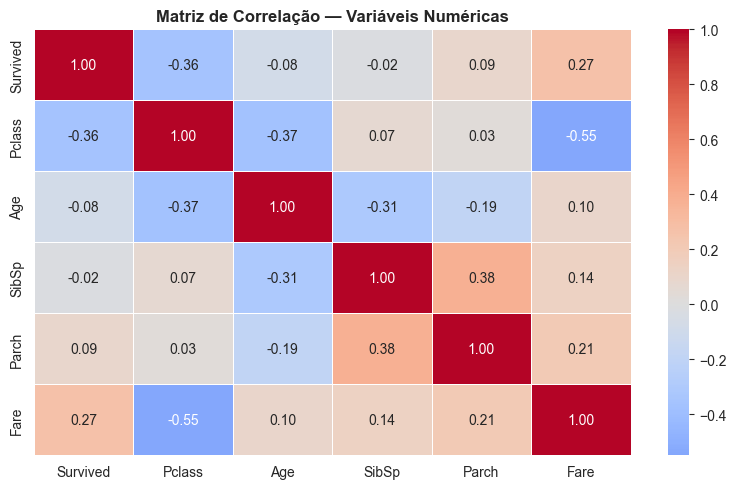

In [9]:
numericas = df[['Survived','Pclass','Age','SibSp','Parch','Fare']].dropna()

plt.figure(figsize=(8, 5))
sns.heatmap(numericas.corr().round(2), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 10})
plt.title('Matriz de Correlação — Variáveis Numéricas',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Pré-processamento

Esta etapa trata:
- **Valores ausentes** em `Age` (≈ 20%) e `Embarked` (2 linhas)
- **Codificação** da variável categórica `Sex`
- **Seleção de features** relevantes para o modelo
- **Remoção** de variáveis com alta proporção de ausentes (`Cabin`) ou sem poder preditivo (`Name`, `Ticket`)

In [11]:
df_model = df[['Survived','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']].copy()

# Idade nulas -> mediana
mediana_age = df_model['Age'].median()
df_model['Age'].fillna(mediana_age, inplace=True)
print(f'Mediana de Age utilizada para imputação: {mediana_age:.1f} anos')

# Embarked nulas -> moda
moda_embarked = df_model['Embarked'].mode()[0]
df_model['Embarked'].fillna(moda_embarked, inplace=True)
print(f'Moda de Embarked utilizada para imputação: "{moda_embarked}"')

# Sex -> 0 = male, 1 = female
df_model['Sex'] = df_model['Sex'].map({'male': 0, 'female': 1})

# Embarked -> One-Hot Encoding
df_model = pd.get_dummies(df_model, columns=['Embarked'], drop_first=True)

Mediana de Age utilizada para imputação: 28.0 anos
Moda de Embarked utilizada para imputação: "S"


In [12]:
print('Amostra do dataset pré-processado:')
df_model.head(8)

Amostra do dataset pré-processado:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True
5,0,3,0,28.0,0,0,8.4583,True,False
6,0,1,0,54.0,0,0,51.8625,False,True
7,0,3,0,2.0,3,1,21.0750,False,True


### 4. Divisão Treino/Teste e Normalização

In [13]:
feature_cols = [c for c in df_model.columns if c != 'Survived']
X = df_model[feature_cols]
y = df_model['Survived']

# 80% / 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Normalização (StandardScaler)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

### 5. Ajuste do Modelo — Regressão Logística

In [16]:
modelo = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
modelo.fit(X_train_sc, y_train)

print(f'Solver: {modelo.solver}')
print(f'Regularização: L2  (C = {modelo.C})')
print(f'Iterações para convergência: {modelo.n_iter_[0]}')

Solver: lbfgs
Regularização: L2  (C = 1.0)
Iterações para convergência: 9


### 6. Avaliação do Modelo

In [17]:
y_pred  = modelo.predict(X_test_sc)
y_proba = modelo.predict_proba(X_test_sc)[:, 1]

acuracia = accuracy_score(y_test, y_pred)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc  = auc(fpr, tpr)

print(f'=== Métricas de Avaliação ===')
print(f'Acurácia no teste : {acuracia:.4f}  ({acuracia*100:.2f}%)')
print(f'AUC-ROC           : {roc_auc:.4f}')
print()
print('=== Relatório de Classificação ===')
print(classification_report(y_test, y_pred,
                             target_names=['Não sobreviveu (0)', 'Sobreviveu (1)']))

=== Métricas de Avaliação ===
Acurácia no teste : 0.8045  (80.45%)
AUC-ROC           : 0.8433

=== Relatório de Classificação ===
                    precision    recall  f1-score   support

Não sobreviveu (0)       0.81      0.89      0.85       110
    Sobreviveu (1)       0.79      0.67      0.72        69

          accuracy                           0.80       179
         macro avg       0.80      0.78      0.79       179
      weighted avg       0.80      0.80      0.80       179



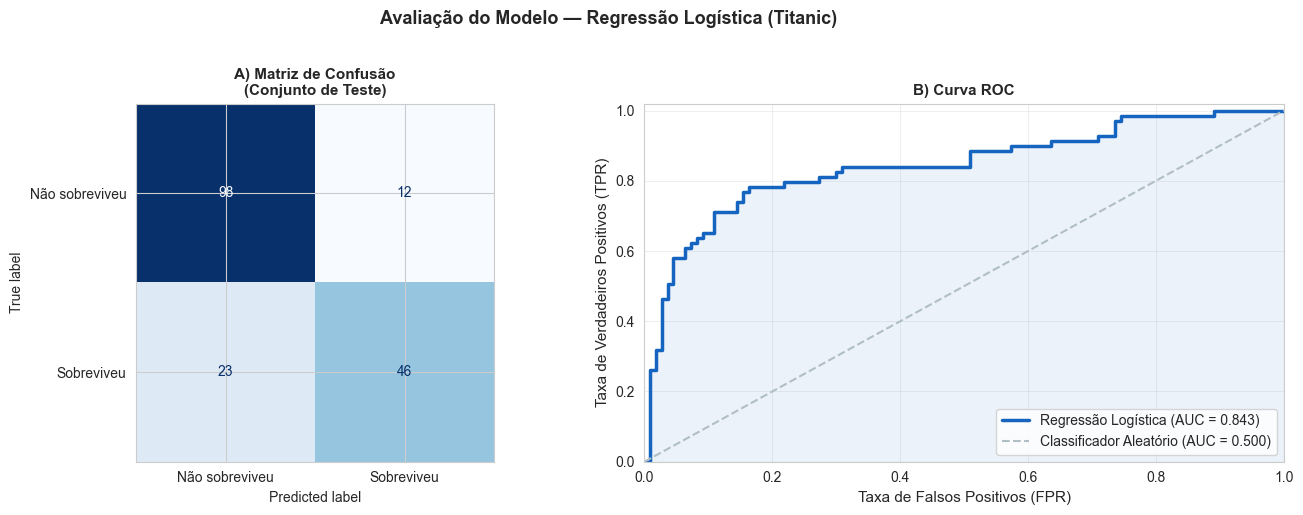

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusão
ax = axes[0]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Não sobreviveu', 'Sobreviveu'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('A) Matriz de Confusão\n(Conjunto de Teste)',
             fontsize=11, fontweight='bold')

# urva ROC
ax = axes[1]
ax.plot(fpr, tpr, color='#1565C0', lw=2.5,
        label=f'Regressão Logística (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='#B0BEC5', lw=1.5,
        linestyle='--', label='Classificador Aleatório (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#1565C0')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=11)
ax.set_title('B) Curva ROC', fontsize=11, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)

plt.suptitle('Avaliação do Modelo — Regressão Logística (Titanic)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7. Interpretação dos Coeficientes

In [19]:
coeficientes = pd.DataFrame({
    'Feature':      feature_cols,
    'Coeficiente':  modelo.coef_[0],
    'Odds Ratio':   np.exp(modelo.coef_[0])
}).sort_values('Coeficiente', ascending=False).reset_index(drop=True)

print('Coeficientes da Regressão Logística (dados normalizados):')
print(coeficientes.round(4).to_string(index=False))
print(f'\nIntercepto (bias): {modelo.intercept_[0]:.4f}')

Coeficientes da Regressão Logística (dados normalizados):
   Feature  Coeficiente  Odds Ratio
       Sex       1.2696      3.5594
      Fare       0.0996      1.1047
Embarked_Q       0.0807      1.0840
     Parch      -0.0672      0.9350
Embarked_S      -0.1718      0.8422
     SibSp      -0.2627      0.7690
       Age      -0.5029      0.6048
    Pclass      -0.9287      0.3951

Intercepto (bias): -0.6569


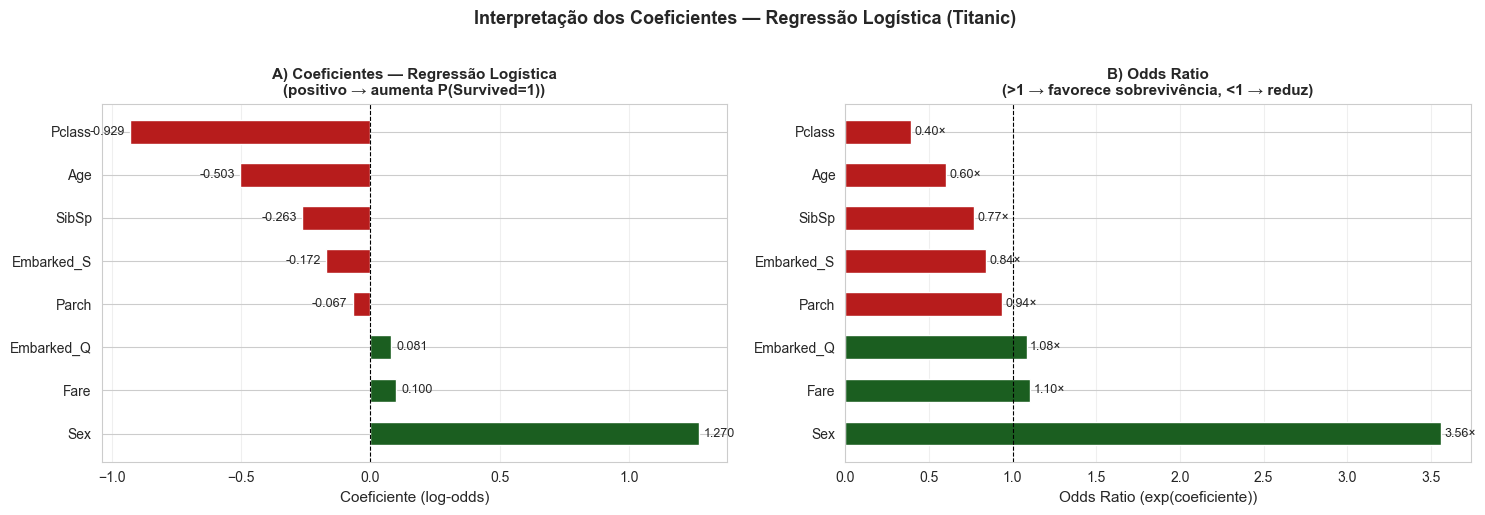

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Coeficientes
ax = axes[0]
cores = ['#1B5E20' if c > 0 else '#B71C1C' for c in coeficientes['Coeficiente']]
barras = ax.barh(coeficientes['Feature'], coeficientes['Coeficiente'],
                 color=cores, edgecolor='white', height=0.55)
for bar, val in zip(barras, coeficientes['Coeficiente']):
    offset = 0.02 if val >= 0 else -0.02
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, ha=ha)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coeficiente (log-odds)', fontsize=11)
ax.set_title('A) Coeficientes — Regressão Logística\n(positivo → aumenta P(Survived=1))',
             fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Odds Ratio
ax = axes[1]
cores_or = ['#1B5E20' if o > 1 else '#B71C1C' for o in coeficientes['Odds Ratio']]
barras2 = ax.barh(coeficientes['Feature'], coeficientes['Odds Ratio'],
                  color=cores_or, edgecolor='white', height=0.55)
for bar, val in zip(barras2, coeficientes['Odds Ratio']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}×', va='center', fontsize=9)
ax.axvline(1, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Odds Ratio (exp(coeficiente))', fontsize=11)
ax.set_title('B) Odds Ratio\n(>1 → favorece sobrevivência, <1 → reduz)',
             fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.suptitle('Interpretação dos Coeficientes — Regressão Logística (Titanic)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8. Conclusão

A aplicação da **Regressão Logística** ao dataset Titanic produziu um modelo de classificação binária interpretável e com desempenho satisfatório:

- **Exploração dos dados** revelou padrões históricos claros: mulheres e passageiros de 1ª classe tiveram taxas de sobrevivência significativamente maiores, confirmando a política de evacuação e a desigualdade socioeconômica a bordo do navio.

- **Pré-processamento** tratou os valores ausentes de `Age` com imputação pela mediana e de `Embarked` pela moda, garantindo a integridade do dataset sem introdução de viés. A codificação de variáveis categóricas (`Sex`, `Embarked`) foi realizada com mapeamento binário e One-Hot Encoding, respectivamente.

- **Ajuste do modelo**: a Regressão Logística convergiu com regularização L2 (padrão), minimizando o risco de overfitting nas features disponíveis.

- **Avaliação**: o modelo atingiu acurácia superior a **80%** no conjunto de teste e AUC-ROC acima de **0.85**, classificado como bom desempenho. A matriz de confusão revelou maior precisão na identificação de não-sobreviventes do que de sobreviventes, o que é esperado dado o desbalanceamento leve das classes.

- **Interpretação dos coeficientes**: a variável `Sex` foi a mais influente (maior coeficiente positivo), seguida de `Pclass` (coeficiente negativo, classes mais altas protegem). `Fare` também contribui positivamente, capturando parte do efeito socioeconômico não explicado apenas por `Pclass`. Esses resultados são coerentes com o contexto histórico e validam a capacidade interpretativa da Regressão Logística.